# SOX 週足 メディアン統計

In [19]:
import sys

path_up = ".."
if not path_up in sys.path:
    sys.path.append(path_up)

In [20]:
import datetime
import os

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import mplfinance as mpf
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
import yfinance as yf

from funcs.technical import calc_robust_bollinger

In [21]:
code = "SOX"
symbol = "^%s" % code
yticker = yf.Ticker(symbol)

In [22]:
### 最新のデータが取得されていることを確認 ###
yticker.history(period="5d", interval="1d")

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-06-12 00:00:00-04:00,13053.929688,13513.440430,12986.059570,13371.469727,0,0.0,0.0
2026-06-15 00:00:00-04:00,13901.240234,14134.599609,13860.320312,14099.620117,0,0.0,0.0
2026-06-16 00:00:00-04:00,13968.280273,14133.599609,13291.750000,13294.219727,0,0.0,0.0
2026-06-17 00:00:00-04:00,13694.009766,13965.599609,13471.219727,13477.070312,0,0.0,0.0
2026-06-18 00:00:00-04:00,14084.759766,14461.790039,14062.280273,14341.780273,0,0.0,0.0


In [23]:
# 週足で過去 5 年分のデータを取得
df0 = yticker.history(period="10y", interval="1wk")

# ローソク足のチャートには、そのうち過去 3 年分のみ使用する
dt_last = df0.index[len(df0) - 1]
tdelta_2y = datetime.timedelta(days=365 * 2)
df = df0[df0.index >= dt_last - tdelta_2y]

In [24]:
dt = df.tail(1).index[0]
year_str = f"{dt.year:04d}"
date_str = f"{dt.month:02d}{dt.day:02d}"
date_str

'0615'

## Moving Median

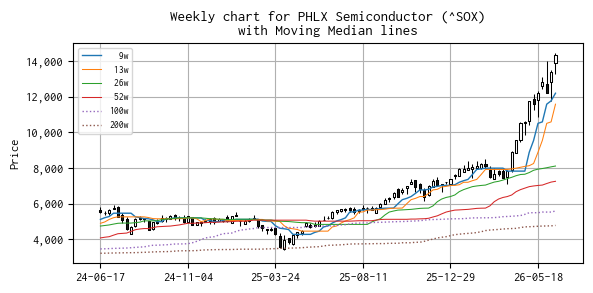

In [25]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 9

fig, ax = plt.subplots(figsize=(6, 3))
'''
fig = plt.figure(figsize=(6, 4))
ax = dict()
n = 2
gs = fig.add_gridspec(
    n, 1, wspace=0.0, hspace=0.0, height_ratios=[3 if i == 0 else 1 for i in range(n)]
)
for i, axis in enumerate(gs.subplots(sharex="col")):
    ax[i] = axis
    ax[i].grid()
'''

mm09 = df0["Close"].rolling(9).median()
mm13 = df0["Close"].rolling(13).median()
mm26 = df0["Close"].rolling(26).median()
mm52 = df0["Close"].rolling(52).median()
mm100 = df0["Close"].rolling(100).median()
mm200 = df0["Close"].rolling(200).median()

apds = [
    mpf.make_addplot(mm09[df.index], width=1, label="  9w", ax=ax),
    mpf.make_addplot(mm13[df.index], width=0.75, label=" 13w", ax=ax),
    mpf.make_addplot(mm26[df.index], width=0.75, label=" 26w", ax=ax),
    mpf.make_addplot(mm52[df.index], width=0.75, label=" 52w", ax=ax),
    mpf.make_addplot(
        mm100[df.index],
        width=1,
        linestyle="dotted",
        label="100w",
        ax=ax,
    ),
    mpf.make_addplot(
        mm200[df.index],
        width=1,
        linestyle="dotted",
        label="200w",
        ax=ax,
    ),
]

mpf.plot(
    df,
    type="candle",
    style="default",
    datetime_format="%y-%m-%d",
    addplot=apds,
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    ax=ax,
)

ax.grid()
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax.set_title(
    f"Weekly chart for {yticker.info["longName"]} ({symbol})\nwith Moving Median lines"
)
ax.legend(loc="upper left", fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(year_str, f"{date_str}_report_weekly_chart_median_{code}.png"))
plt.show()

In [26]:
df.tail(2)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-06-08 00:00:00-04:00,12838.879883,13513.440430,11794.150391,13371.469727,0,0.0,0.0
2026-06-15 00:00:00-04:00,13901.240234,14461.790039,13291.750000,14341.783203,0,0.0,0.0


In [27]:
df.tail(2)["Close"]

Date
2026-06-08 00:00:00-04:00    13371.469727
2026-06-15 00:00:00-04:00    14341.783203
Name: Close, dtype: float64

In [28]:
df.tail(2)["Close"].diff()

Date
2026-06-08 00:00:00-04:00           NaN
2026-06-15 00:00:00-04:00    970.313477
Name: Close, dtype: float64

In [29]:
df["Close"].rolling(9).median().tail(5)

Date
2026-05-18 00:00:00-04:00    10513.660156
2026-05-25 00:00:00-04:00    10595.339844
2026-06-01 00:00:00-04:00    11588.459961
2026-06-08 00:00:00-04:00    11775.500000
2026-06-15 00:00:00-04:00    12202.540039
Name: Close, dtype: float64

In [30]:
df["Close"].rolling(13).median().tail(5)

Date
2026-05-18 00:00:00-04:00     8889.830078
2026-05-25 00:00:00-04:00     9555.879883
2026-06-01 00:00:00-04:00    10513.660156
2026-06-08 00:00:00-04:00    10595.339844
2026-06-15 00:00:00-04:00    11588.459961
Name: Close, dtype: float64

In [31]:
df["Close"].rolling(26).median().tail(5)

Date
2026-05-18 00:00:00-04:00    7942.670166
2026-05-25 00:00:00-04:00    7978.200195
2026-06-01 00:00:00-04:00    8023.545166
2026-06-08 00:00:00-04:00    8073.495117
2026-06-15 00:00:00-04:00    8118.114990
Name: Close, dtype: float64

In [32]:
df["Close"].rolling(52).median().tail(5)

Date
2026-05-18 00:00:00-04:00    7029.359863
2026-05-25 00:00:00-04:00    7050.719971
2026-06-01 00:00:00-04:00    7137.755127
2026-06-08 00:00:00-04:00    7218.150146
2026-06-15 00:00:00-04:00    7261.750000
Name: Close, dtype: float64

In [33]:
df0["Close"].rolling(100).median().tail(5)

Date
2026-05-18 00:00:00-04:00    5499.934814
2026-05-25 00:00:00-04:00    5536.300049
2026-06-01 00:00:00-04:00    5536.300049
2026-06-08 00:00:00-04:00    5536.300049
2026-06-15 00:00:00-04:00    5595.425049
Name: Close, dtype: float64

In [34]:
df0["Close"].rolling(200).median().tail(5)

Date
2026-05-18 00:00:00-04:00    4740.169922
2026-05-25 00:00:00-04:00    4751.379883
2026-06-01 00:00:00-04:00    4757.885010
2026-06-08 00:00:00-04:00    4762.405029
2026-06-15 00:00:00-04:00    4787.389893
Name: Close, dtype: float64

## Robust Bollinger bands

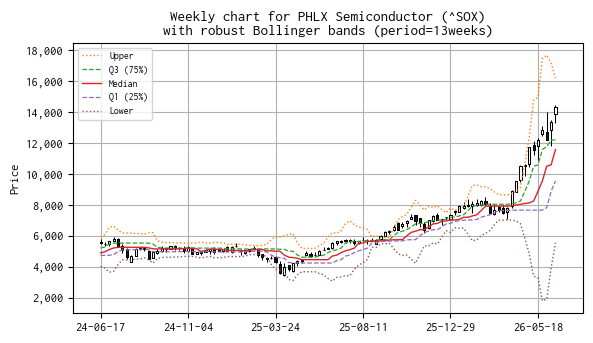

In [35]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 9

fig, ax = plt.subplots(figsize=(6, 3.5))

# Bollinger bands
period = 13
mv_median = df0["Close"].rolling(period).median()
mv_q1 = df0["Close"].rolling(period).quantile(0.25)
mv_q3 = df0["Close"].rolling(period).quantile(0.75)
mv_iqr = mv_q3 - mv_q1
mv_lower = mv_q1 - mv_iqr * 1.5
mv_upper = mv_q3 + mv_iqr * 1.5

apds = [
    mpf.make_addplot(
        mv_upper[df.index],
        width=1,
        color="C1",
        linestyle="dotted",
        label="Upper",
        ax=ax,
    ),
    mpf.make_addplot(
        mv_q3[df.index],
        width=0.9,
        color="C2",
        linestyle="dashed",
        label="Q3 (75%)",
        ax=ax,
    ),
    mpf.make_addplot(
        mv_median[df.index],
        width=1,
        color="C3",
        linestyle="solid",
        label="Median",
        ax=ax,
    ),
    mpf.make_addplot(
        mv_q1[df.index],
        width=0.9,
        color="C4",
        linestyle="dashed",
        label="Q1 (25%)",
        ax=ax,
    ),
    mpf.make_addplot(
        mv_lower[df.index],
        width=1,
        color="C5",
        linestyle="dotted",
        label="Lower",
        ax=ax,
    ),
]

mpf.plot(
    df,
    type="candle",
    style="default",
    addplot=apds,
    datetime_format="%y-%m-%d",
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    ax=ax,
)

ax.grid()
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax.legend(loc="best", fontsize=7)

try:
    ax.set_title(
        f"Weekly chart for {yticker.info['longName']} ({symbol})\nwith robust Bollinger bands (period={period}weeks)"
    )
except KeyError:
    ax.set_title(
        f"Weekly chart for {symbol}\nwith robust Bollinger bands (period={period}weeks)"
    )

plt.tight_layout()
plt.savefig(
    os.path.join(
        year_str, f"{date_str}_report_weekly_chart_bollinger_robust_{code}.png"
    )
)
plt.show()

## ヒストグラムと Q-Q プロット

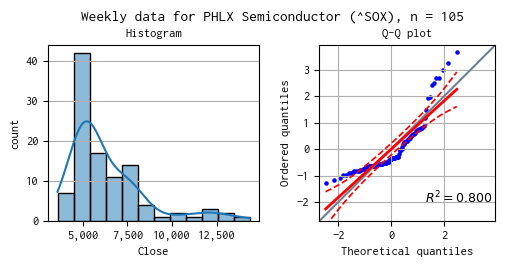

In [36]:
plt.rcParams["font.size"] = 9
fig, axes = plt.subplots(1, 2, figsize=(6, 2.5))

sns.histplot(df["Close"], kde=True, ax=axes[0])

# ヒストグラム
axes[0].set_xlabel("Close")
axes[0].set_ylabel("count")
axes[0].xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
axes[0].grid(axis="y")
axes[0].set_title("Histogram", fontsize=9)

# Q-Q プロット
pg.qqplot(df["Close"], s=5, ax=axes[1])
axes[1].set_title("Q-Q plot", fontsize=9)
axes[1].grid()

plt.suptitle(
    "Weekly data for %s (%s), n = %d" % (yticker.info["longName"], symbol, len(df)),
    fontsize=11,
)
plt.subplots_adjust(top=0.84, bottom=0.135, wspace=0.2)
plt.savefig(
    os.path.join(year_str, f"{date_str}_report_weekly_histogram_qqplot_{code}.png")
)
plt.show()